# Regularization Techniques and ML Pipeline

This notebook covers different regularization techniques and how to build an end-to-end machine learning pipeline.

## Topics Covered:
1. Ridge Regression (L2)
2. Lasso Regression (L1)
3. Elastic Net
4. Building a Complete Pipeline

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error

%matplotlib inline


## 1. Generate Complex Synthetic Data

In [4]:
np.random.seed(42)
n_samples = 1000
n_features = 20

# Generate features with different scales
X = np.random.randn(n_samples, n_features)
X[:, 0:5] *= 100  # Make first 5 features have larger scale
X[:, 5:10] *= 0.01  # Make next 5 features have smaller scale

# True coefficients: only first 5 features are actually important
true_coef = np.zeros(n_features)
true_coef[:5] = [1, 0.5, -0.8, 0.3, -0.4]

# Generate target with noise
y = np.dot(X, true_coef) + np.random.normal(0, 0.1, n_samples)

# Create DataFrame
feature_names = [f'X{i+1}' for i in range(n_features)]
data = pd.DataFrame(X, columns=feature_names)
data['y'] = y

## 2. Comparing Different Regularization Techniques

Model Comparison:
        Model  Alpha  Train R²   Test R²  Features Selected
0       Ridge    0.1  1.000000  0.999999                 20
1       Lasso    0.1  0.999997  0.999997                  5
2  ElasticNet    0.1  0.997618  0.997600                 19
3       Ridge    1.0  0.999998  0.999998                 20
4       Lasso    1.0  0.999767  0.999798                  5
5  ElasticNet    1.0  0.885307  0.884927                 19
6       Ridge   10.0  0.999843  0.999840                 20
7       Lasso   10.0  0.976791  0.979976                  5
8  ElasticNet   10.0  0.286187  0.286148                 10


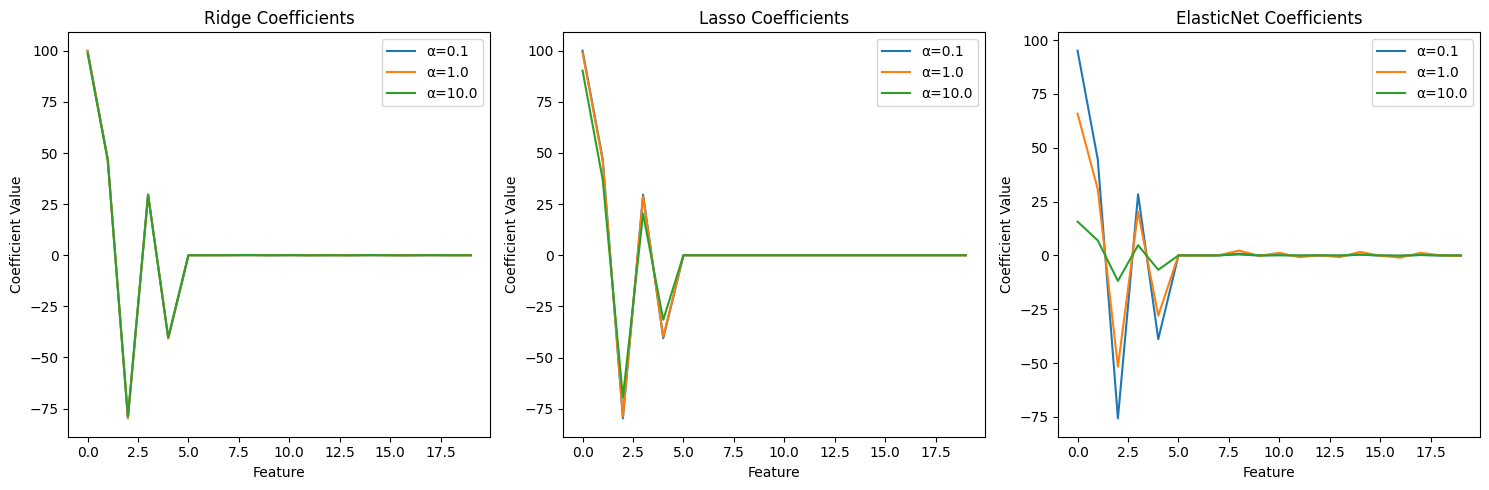

In [5]:
def compare_models(X, y, alphas=[0.1, 1.0, 10.0]):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    results = []
    
    for alpha in alphas:
        # Train models
        ridge = Ridge(alpha=alpha)
        lasso = Lasso(alpha=alpha)
        elastic = ElasticNet(alpha=alpha, l1_ratio=0.5)
        
        models = {
            'Ridge': ridge,
            'Lasso': lasso,
            'ElasticNet': elastic
        }
        
        for name, model in models.items():
            model.fit(X_train_scaled, y_train)
            train_score = model.score(X_train_scaled, y_train)
            test_score = model.score(X_test_scaled, y_test)
            coef = model.coef_
            n_selected = np.sum(coef != 0)
            
            results.append({
                'Model': name,
                'Alpha': alpha,
                'Train R²': train_score,
                'Test R²': test_score,
                'Features Selected': n_selected,
                'Coefficients': coef
            })
    
    return pd.DataFrame(results)

# Compare models
results = compare_models(data.drop('y', axis=1), data['y'])
print("Model Comparison:")
print(results[['Model', 'Alpha', 'Train R²', 'Test R²', 'Features Selected']])

# Plot coefficients for each model
plt.figure(figsize=(15, 5))
for i, model in enumerate(['Ridge', 'Lasso', 'ElasticNet']):
    plt.subplot(1, 3, i+1)
    model_results = results[results['Model'] == model]
    for _, row in model_results.iterrows():
        plt.plot(row['Coefficients'], label=f'α={row["Alpha"]}')
    plt.title(f'{model} Coefficients')
    plt.xlabel('Feature')
    plt.ylabel('Coefficient Value')
    plt.legend()
plt.tight_layout()
plt.show()

## 3. Building a Complete Pipeline

Best parameters: {'regressor__alpha': 0.1, 'regressor__l1_ratio': 0.9}
Best cross-validation score: 0.9998426473850648


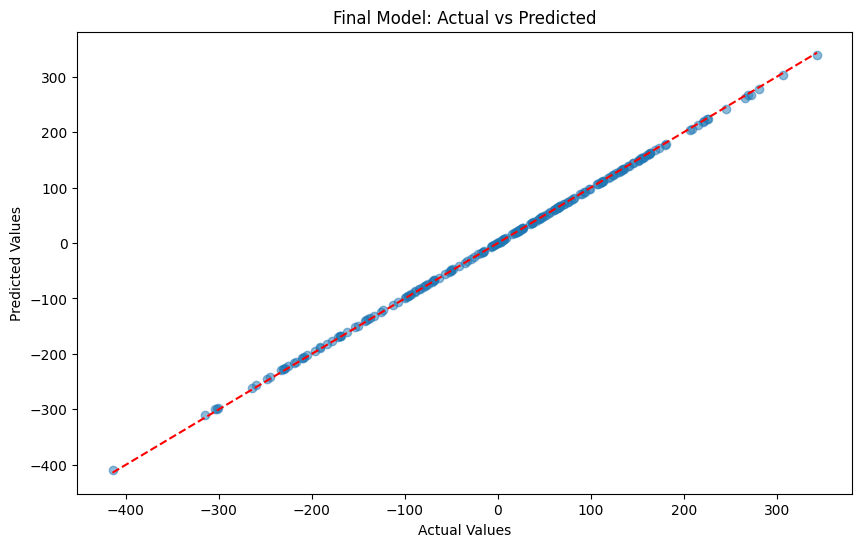


Final Model Performance:
R² Score: 0.9999
RMSE: 1.6528


In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV

# Create a pipeline
def create_pipeline():
    # Feature processing
    numeric_features = data.drop('y', axis=1).columns
    
    numeric_transformer = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features)
        ])
    
    # Full pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', ElasticNet())
    ])
    
    return pipeline

# Create and train pipeline
pipeline = create_pipeline()

# Define parameter grid
param_grid = {
    'regressor__alpha': [0.1, 1.0, 10.0],
    'regressor__l1_ratio': [0.1, 0.5, 0.9]
}

# Perform grid search
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# Split data
X = data.drop('y', axis=1)
y = data['y']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit grid search
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Make predictions with best model
y_pred = grid_search.predict(X_test)

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Final Model: Actual vs Predicted')
plt.show()

# Print final metrics
print("\nFinal Model Performance:")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")